# PVOL Model — End-to-End Test

This notebook walks through the full PVOL computation pipeline defined in `MODEL.md`, using real Polymarket data from **February 1, 2026** (BTC at $78,726) as the test fixture.

The same data was used in `skew_model.ipynb` for the DCA skew experiments — we reuse it here to test the IV inversion and PVOL aggregation pipeline.

**Pipeline steps (matching MODEL.md sections):**

| Step | MODEL.md section | What it does |
|------|------------------|--------------|
| 1 | §3 | Probability input selection (midquote vs last price) |
| 2 | §4 | Ladder cleaning (drop non-monotone rungs) |
| 3 | §5 | Per-strike IV extraction (invert reflection formula) |
| 4 | §6 | PVOL index aggregation (touch-band-weighted average) |
| 5 | §7 | Data quality flags |

---

In [1]:
import numpy as np
from scipy.stats import norm
from datetime import datetime, timezone
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print('imports ok')

imports ok


---
## Test Fixture — Feb 1, 2026 Snapshot

This is a real Polymarket snapshot. BTC was trading at **$78,726** on February 1, 2026 at midnight UTC.

The contract month is February 2026, expiring February 28, 2026.

**Note on bid/ask:** In this historical dataset, we only have last-traded YES prices — no bid/ask spread data. So `P_hat = yes_price` for all rungs. In production, the midquote would be preferred (see Step 1 below).

**Non-monotone rung to watch:** The $120k upside strike is priced at 0.027, which is *higher* than $115k at 0.025. This is a logical impossibility (a more distant level cannot be more likely to be touched). Step 2 will catch and drop this.

In [2]:
# ── Snapshot metadata ──────────────────────────────────────────────────────────
SPOT        = 78_726.0
SNAPSHOT_TS = datetime(2026, 2,  1,  0,  0,  0, tzinfo=timezone.utc)
EXPIRY_TS   = datetime(2026, 2, 28, 23, 59, 59, tzinfo=timezone.utc)

# T in years — denominator of the IV formula
T = (EXPIRY_TS - SNAPSHOT_TS).total_seconds() / (365.25 * 86_400)

print(f'Snapshot : {SNAPSHOT_TS.date()}')
print(f'Expiry   : {EXPIRY_TS.date()}')
print(f'T        = {T:.5f} years  ({T * 365.25:.1f} days to expiry)')
print(f'Spot     = ${SPOT:,.0f}')

# ── Raw ladder data ────────────────────────────────────────────────────────────
# Format: {strike_H: yes_price}  (last traded price — no bid/ask in this dataset)
# Upside strikes are ABOVE spot; sorted ascending (nearest first)
upside_raw = {
     85_000: 0.5500,
     90_000: 0.2700,
     95_000: 0.1500,
    100_000: 0.0800,
    105_000: 0.0530,
    110_000: 0.0355,
    115_000: 0.0250,
    120_000: 0.0270,   # ← NON-MONOTONE: 0.027 > 0.025 at $115k
    125_000: 0.0215,
    150_000: 0.0115,
}

# Downside strikes are BELOW spot; sorted descending (nearest first)
downside_raw = {
     75_000: 0.6750,
     70_000: 0.3400,
     65_000: 0.1600,
     60_000: 0.0900,
     55_000: 0.0580,
     50_000: 0.0345,
     45_000: 0.0285,
     40_000: 0.0230,
     35_000: 0.0210,
}

print(f'\nUpside rungs:   {len(upside_raw)}')
print(f'Downside rungs: {len(downside_raw)}')

Snapshot : 2026-02-01
Expiry   : 2026-02-28
T        = 0.07666 years  (28.0 days to expiry)
Spot     = $78,726

Upside rungs:   10
Downside rungs: 9


---
## Step 1 — Probability Input Selection (MODEL.md §3)

The inversion formula takes `P_hat`, the **market-implied touch probability proxy**.

Production rule (priority order):
1. If `yes_bid` and `yes_ask` both exist → use midquote: `P_hat = (bid + ask) / 2`
2. Otherwise → use last traded price: `P_hat = yes_price`
3. Always clamp: `P_hat = clamp(P_hat, ε, 1 − ε)` with `ε = 0.001`

**Why clamp?** The inversion calls `norm.ppf(P_hat / 2)`. As `P_hat → 0`, `norm.ppf(0) = -∞`. As `P_hat → 1`, `norm.ppf(0.5) = 0`, causing division by zero. Clamping prevents numerical blowup.

**Why midquote over last trade?** The last traded price reflects a historical transaction. The midquote reflects what market makers are willing to buy/sell *right now* — a better estimate of the current consensus probability.

In [3]:
EPSILON = 0.001  # clamp boundary

def get_probability_proxy(
    yes_price: float,
    yes_bid: float | None = None,
    yes_ask: float | None = None,
) -> tuple[float, str]:
    """
    Select P_hat per MODEL.md §3.
    Returns (P_hat, source) where source is 'midquote' or 'last_traded'.
    """
    if yes_bid is not None and yes_ask is not None:
        raw = (yes_bid + yes_ask) / 2.0
        source = 'midquote'
    else:
        raw = yes_price
        source = 'last_traded'

    clamped = float(np.clip(raw, EPSILON, 1.0 - EPSILON))
    return clamped, source


# ── Demonstrate on a few cases ─────────────────────────────────────────────────
cases = [
    ('has bid/ask',    0.57, 0.56, 0.58),
    ('no bid/ask',     0.57, None, None),
    ('near-zero prob', 0.0005, None, None),   # would blow up without clamp
    ('near-one prob',  0.9998, None, None),   # same
]

print(f'{"Case":<22} {"P_hat":>8}  {"Source"}')
print('-' * 45)
for label, yp, yb, ya in cases:
    p, src = get_probability_proxy(yp, yb, ya)
    print(f'{label:<22} {p:>8.4f}  {src}')

# ── Apply to our test data (last-traded only — no bid/ask in this dataset) ─────
print('\n--- Applying to Feb 2026 snapshot (all last_traded) ---')
upside_probs   = {h: get_probability_proxy(p)[0] for h, p in upside_raw.items()}
downside_probs = {h: get_probability_proxy(p)[0] for h, p in downside_raw.items()}

Case                      P_hat  Source
---------------------------------------------
has bid/ask              0.5700  midquote
no bid/ask               0.5700  last_traded
near-zero prob           0.0010  last_traded
near-one prob            0.9990  last_traded

--- Applying to Feb 2026 snapshot (all last_traded) ---


---
## Step 2 — Ladder Cleaning (MODEL.md §4)

Touch probabilities must be **strictly decreasing** with barrier distance from spot:

```
P(H₁) > P(H₂) > ... > P(Hₙ)   where |H₁ - S| < |H₂ - S| < ...
```

A more distant barrier is always harder to touch. Any violation is a market pricing error or thin-liquidity noise.

**MVP policy:** Scan from the nearest rung outward. At the first violation, drop that rung and everything beyond it on the same side. Emit a `non_monotone_ladder` flag.

**Expected result here:** The $120k upside rung (prob = 0.027) is priced above $115k (prob = 0.025). The cleaner should drop $120k, $125k, and $150k — leaving 7 clean upside rungs.

In [4]:
def clean_ladder(probs: dict[float, float]) -> tuple[dict[float, float], bool]:
    """
    Enforce strict monotonic decrease in touch probability with barrier distance.

    Input:  {strike: P_hat}, strikes in order of increasing distance from spot
            (caller is responsible for correct ordering).
    Output: (clean_probs, was_non_monotone)
            clean_probs = probs up to (not including) the first violation
            was_non_monotone = True if any rungs were dropped
    """
    strikes = list(probs.keys())
    clean   = {}
    prev_p  = 1.0  # sentinel — any real probability is less than 1

    for h in strikes:
        p = probs[h]
        if p >= prev_p:
            # Violation: this rung is at least as likely as the previous (closer) one.
            # Drop this rung and everything beyond it.
            break
        clean[h] = p
        prev_p = p

    dropped = len(probs) - len(clean)
    return clean, dropped > 0


# ── Upside: sort by ascending strike (nearest above spot first) ────────────────
upside_sorted  = dict(sorted(upside_probs.items()))   # 85k → 150k
downside_sorted = dict(sorted(downside_probs.items(), reverse=True))  # 75k → 35k

upside_clean,   up_flagged   = clean_ladder(upside_sorted)
downside_clean, down_flagged = clean_ladder(downside_sorted)

# ── Report ─────────────────────────────────────────────────────────────────────
print('UPSIDE LADDER')
print(f'  Before cleaning: {len(upside_sorted)} rungs')
for h, p in upside_sorted.items():
    status = '  OK' if h in upside_clean else '  DROPPED (non-monotone)'
    print(f'    ${h:>7,.0f}  P={p:.4f}{status}')
print(f'  After cleaning:  {len(upside_clean)} rungs  |  flag={up_flagged}')

print('\nDOWNSIDE LADDER')
print(f'  Before cleaning: {len(downside_sorted)} rungs')
for h, p in downside_sorted.items():
    status = '  OK' if h in downside_clean else '  DROPPED'
    print(f'    ${h:>7,.0f}  P={p:.4f}{status}')
print(f'  After cleaning:  {len(downside_clean)} rungs  |  flag={down_flagged}')

UPSIDE LADDER
  Before cleaning: 10 rungs
    $ 85,000  P=0.5500  OK
    $ 90,000  P=0.2700  OK
    $ 95,000  P=0.1500  OK
    $100,000  P=0.0800  OK
    $105,000  P=0.0530  OK
    $110,000  P=0.0355  OK
    $115,000  P=0.0250  OK
    $120,000  P=0.0270  DROPPED (non-monotone)
    $125,000  P=0.0215  DROPPED (non-monotone)
    $150,000  P=0.0115  DROPPED (non-monotone)
  After cleaning:  7 rungs  |  flag=True

DOWNSIDE LADDER
  Before cleaning: 9 rungs
    $ 75,000  P=0.6750  OK
    $ 70,000  P=0.3400  OK
    $ 65,000  P=0.1600  OK
    $ 60,000  P=0.0900  OK
    $ 55,000  P=0.0580  OK
    $ 50,000  P=0.0345  OK
    $ 45,000  P=0.0285  OK
    $ 40,000  P=0.0230  OK
    $ 35,000  P=0.0210  OK
  After cleaning:  9 rungs  |  flag=False


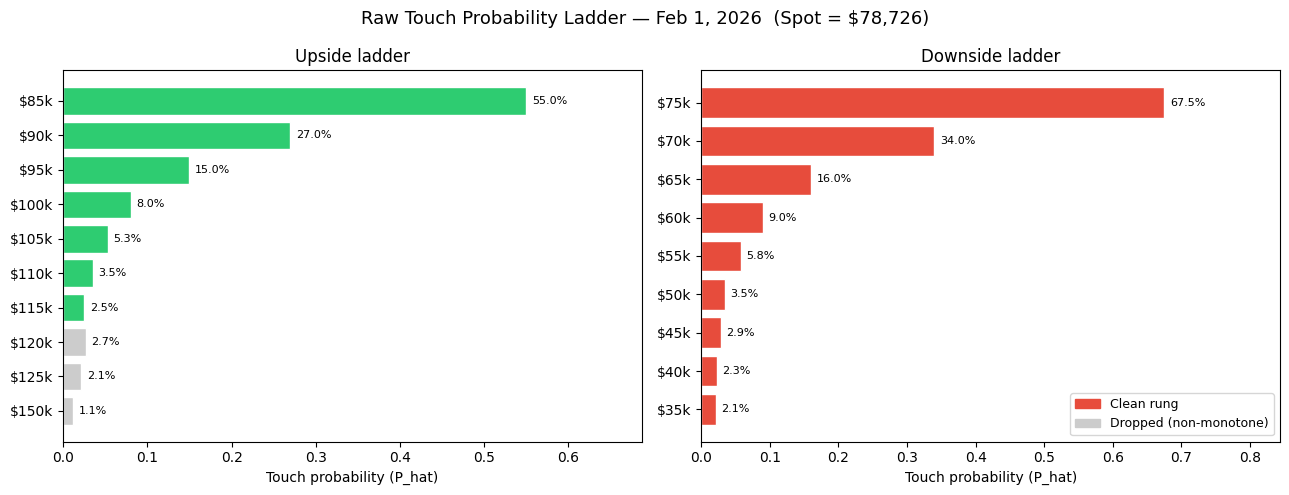

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Raw Touch Probability Ladder — Feb 1, 2026  (Spot = $78,726)', fontsize=13)

for ax, raw, clean, label, color in [
    (axes[0], upside_sorted,   upside_clean,   'Upside',   '#2ecc71'),
    (axes[1], downside_sorted, downside_clean, 'Downside', '#e74c3c'),
]:
    strikes = list(raw.keys())
    probs   = list(raw.values())
    colors  = [color if h in clean else '#cccccc' for h in strikes]
    labels  = [f'${h//1000}k' for h in strikes]

    bars = ax.barh(labels, probs, color=colors, edgecolor='white')
    ax.bar_label(bars, fmt=lambda x: f'{x:.1%}', padding=4, fontsize=8)
    ax.set_xlim(0, max(probs) * 1.25)
    ax.set_xlabel('Touch probability (P_hat)')
    ax.set_title(f'{label} ladder')
    ax.invert_yaxis()  # nearest strike at top

dropped = mpatches.Patch(color='#cccccc', label='Dropped (non-monotone)')
kept    = mpatches.Patch(color=color,     label='Clean rung')
axes[1].legend(handles=[kept, dropped], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

---
## Step 3 — Per-Strike IV Extraction (MODEL.md §5)

With `P_hat`, `H`, `S`, and `T` in hand, invert the reflection-principle formula:

$$\sigma = \frac{|\ln(H/S)|}{\sqrt{T} \cdot |\Phi^{-1}(P_{\text{hat}} / 2)|}$$

**Where each term comes from:**

- `|ln(H/S)|` — log-distance between strike and spot. This is the natural distance metric for log-normal assets: equal percentage moves up and down are equally likely, so log-distance is symmetric.
- `√T` — time scaling. Brownian motion spreads as √time, so a longer horizon makes it easier to touch distant levels.
- `|Φ⁻¹(P/2)|` — the standard normal quantile. The factor of 2 comes from the reflection principle: P_touch ≈ 2 × P_terminal, so we halve P before inverting.

**Sanity check:** Higher touch probability → smaller `|Φ⁻¹(P/2)|` → larger σ. ✓ (A more volatile asset is more likely to touch any given level.)

For each rung we also attach a `valid` flag — False if any input is degenerate (T ≤ 0, H or S ≤ 0, P_hat too close to boundary).

In [6]:
def extract_iv(
    H: float,
    S: float,
    T: float,
    P_hat: float,
) -> tuple[float | None, bool, str]:
    """
    Invert the zero-drift log-Brownian first-passage formula for implied vol.

    Returns (sigma, valid, reason)
      sigma  — annualized implied vol, or None if invalid
      valid  — False if any input is degenerate
      reason — human-readable note
    """
    if T <= 0:
        return None, False, 'T <= 0 (expired)'
    if H <= 0 or S <= 0:
        return None, False, 'negative price'
    if P_hat <= EPSILON or P_hat >= 1.0 - EPSILON:
        return None, False, 'P_hat at clamp boundary'

    log_dist  = abs(np.log(H / S))             # |ln(H/S)|
    quantile  = abs(norm.ppf(P_hat / 2.0))     # |Φ⁻¹(P/2)|
    sigma     = log_dist / (np.sqrt(T) * quantile)
    return sigma, True, 'ok'


# ── Apply to all clean rungs ───────────────────────────────────────────────────
results_up   = []
results_down = []

for h, p in upside_clean.items():
    sigma, valid, reason = extract_iv(h, SPOT, T, p)
    results_up.append({'side': 'up', 'strike': h, 'P_hat': p, 'sigma': sigma, 'valid': valid, 'note': reason})

for h, p in downside_clean.items():
    sigma, valid, reason = extract_iv(h, SPOT, T, p)
    results_down.append({'side': 'down', 'strike': h, 'P_hat': p, 'sigma': sigma, 'valid': valid, 'note': reason})

df_up   = pd.DataFrame(results_up)
df_down = pd.DataFrame(results_down)
df_all  = pd.concat([df_up, df_down], ignore_index=True)

# ── Display per-strike smile ───────────────────────────────────────────────────
print('PER-STRIKE IMPLIED VOLATILITY')
print(f'  Spot = ${SPOT:,.0f}   T = {T*365.25:.1f} days\n')
print(f'  {"Side":<6} {"Strike":>8}  {"P_hat":>7}  {"σ (ann.)":>9}  Note')
print('  ' + '-' * 50)
for _, row in df_all.iterrows():
    sigma_str = f"{row['sigma']:.1%}" if row['valid'] else 'INVALID'
    print(f"  {row['side']:<6} ${row['strike']:>7,.0f}  {row['P_hat']:>7.4f}  {sigma_str:>9}  {row['note']}")

PER-STRIKE IMPLIED VOLATILITY
  Spot = $78,726   T = 28.0 days

  Side     Strike    P_hat   σ (ann.)  Note
  --------------------------------------------------
  up     $ 85,000   0.5500      46.3%  ok
  up     $ 90,000   0.2700      43.8%  ok
  up     $ 95,000   0.1500      47.1%  ok
  up     $100,000   0.0800      49.3%  ok
  up     $105,000   0.0530      53.8%  ok
  up     $110,000   0.0355      57.5%  ok
  up     $115,000   0.0250      61.1%  ok
  down   $ 75,000   0.6750      41.8%  ok
  down   $ 70,000   0.3400      44.5%  ok
  down   $ 65,000   0.1600      49.2%  ok
  down   $ 60,000   0.0900      57.9%  ok
  down   $ 55,000   0.0580      68.3%  ok
  down   $ 50,000   0.0345      77.6%  ok
  down   $ 45,000   0.0285      92.2%  ok
  down   $ 40,000   0.0230     107.6%  ok
  down   $ 35,000   0.0210     126.9%  ok


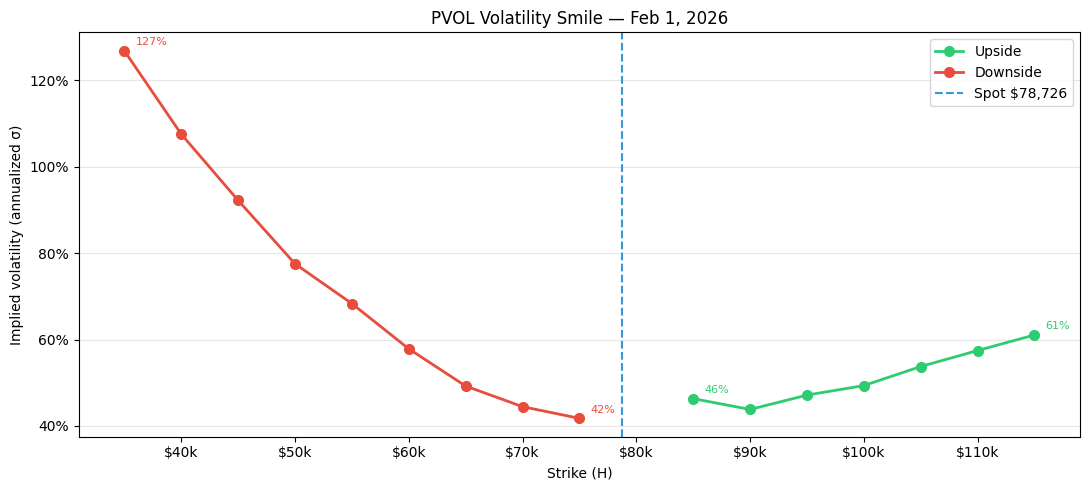

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

up_valid   = df_up[df_up['valid']].sort_values('strike')
down_valid = df_down[df_down['valid']].sort_values('strike', ascending=False)

ax.plot(up_valid['strike'],   up_valid['sigma'],   'o-', color='#2ecc71', label='Upside',   linewidth=2, markersize=7)
ax.plot(down_valid['strike'], down_valid['sigma'],  'o-', color='#e74c3c', label='Downside', linewidth=2, markersize=7)

# Spot line
ax.axvline(SPOT, color='#3498db', linestyle='--', linewidth=1.5, label=f'Spot ${SPOT:,.0f}')

# Annotate a few key points
for _, row in up_valid.iloc[[0, -1]].iterrows():
    ax.annotate(f"{row['sigma']:.0%}", xy=(row['strike'], row['sigma']),
                xytext=(8, 4), textcoords='offset points', fontsize=8, color='#2ecc71')
for _, row in down_valid.iloc[[0, -1]].iterrows():
    ax.annotate(f"{row['sigma']:.0%}", xy=(row['strike'], row['sigma']),
                xytext=(8, 4), textcoords='offset points', fontsize=8, color='#e74c3c')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('Strike (H)')
ax.set_ylabel('Implied volatility (annualized σ)')
ax.set_title('PVOL Volatility Smile — Feb 1, 2026')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 4 — PVOL Index Aggregation (MODEL.md §6)

The per-strike IVs form a **volatility smile** — now we collapse it into one number.

**Touch-band weights:** Each rung gets a weight equal to the probability mass in its band — the gap between its own touch probability and the next rung out:

$$w_i = P_i - P_{i+1}$$

The final (outermost clean) rung receives `w_final = P_final` (its own probability, representing the tail).

**Why this weighting?** It mirrors how a vol swap or variance swap weights strikes by the probability density at each level. Rungs where the market has dense conviction (large probability gap to the next rung) count more. Thin outer markets contribute proportionally less.

**PVOL index:**

$$\text{PVOL} = \frac{\sum_i w_i \cdot \sigma_i}{\sum_i w_i}$$

We compute PVOL separately for upside and downside, then combine all valid rungs for the overall index.

In [8]:
def compute_pvol(df_side: pd.DataFrame) -> tuple[float | None, pd.DataFrame]:
    """
    Compute touch-band-weighted PVOL for one side of the ladder.

    Expects df_side sorted by increasing barrier distance (nearest first),
    with columns: strike, P_hat, sigma, valid.

    Returns (pvol, df_with_weights).
    Fallback: if fewer than 2 valid rungs, return simple average and flag it.
    """
    valid = df_side[df_side['valid']].copy().reset_index(drop=True)

    if len(valid) == 0:
        return None, df_side

    # Touch-band weights: w_i = P_i - P_{i+1}; last rung gets w = P_final
    probs  = valid['P_hat'].values
    weights = np.empty(len(probs))
    for i in range(len(probs) - 1):
        weights[i] = probs[i] - probs[i + 1]
    weights[-1] = probs[-1]  # tail weight for outermost rung

    valid['weight'] = weights
    valid['contribution'] = valid['weight'] * valid['sigma']

    if len(valid) < 2:
        # Fallback: simple average
        pvol = valid['sigma'].mean()
        valid['fallback'] = True
    else:
        pvol = valid['contribution'].sum() / valid['weight'].sum()
        valid['fallback'] = False

    return pvol, valid


# ── Compute per-side PVOL ──────────────────────────────────────────────────────
# Sort by increasing barrier distance (nearest rung first)
df_up_sorted   = df_up.copy()
df_down_sorted = df_down.copy()

pvol_up,   up_weights   = compute_pvol(df_up_sorted)
pvol_down, down_weights = compute_pvol(df_down_sorted)

# ── Compute combined PVOL (all valid rungs together) ──────────────────────────
# Re-sort entire ladder by barrier distance from spot
df_all['dist'] = abs(np.log(df_all['strike'] / SPOT))
df_combined    = df_all.sort_values('dist').reset_index(drop=True)
pvol_combined, combined_weights = compute_pvol(df_combined)

# ── Print weight table ─────────────────────────────────────────────────────────
print('TOUCH-BAND WEIGHTS — UPSIDE')
print(f'  {"Strike":>8}  {"P_hat":>7}  {"weight":>8}  {"σ":>8}  {"contrib":>8}')
for _, row in up_weights.iterrows():
    print(f"  ${row['strike']:>7,.0f}  {row['P_hat']:>7.4f}  {row['weight']:>8.4f}  {row['sigma']:>8.1%}  {row['contribution']:>8.4f}")
print(f'  {"PVOL (up)":>30}  {pvol_up:>8.1%}')

print('\nTOUCH-BAND WEIGHTS — DOWNSIDE')
print(f'  {"Strike":>8}  {"P_hat":>7}  {"weight":>8}  {"σ":>8}  {"contrib":>8}')
for _, row in down_weights.iterrows():
    print(f"  ${row['strike']:>7,.0f}  {row['P_hat']:>7.4f}  {row['weight']:>8.4f}  {row['sigma']:>8.1%}  {row['contribution']:>8.4f}")
print(f'  {"PVOL (down)":>30}  {pvol_down:>8.1%}')

print(f'\n  PVOL (combined) = {pvol_combined:.1%}')

TOUCH-BAND WEIGHTS — UPSIDE
    Strike    P_hat    weight         σ   contrib
  $ 85,000   0.5500    0.2800     46.3%    0.1297
  $ 90,000   0.2700    0.1200     43.8%    0.0526
  $ 95,000   0.1500    0.0700     47.1%    0.0330
  $100,000   0.0800    0.0270     49.3%    0.0133
  $105,000   0.0530    0.0175     53.8%    0.0094
  $110,000   0.0355    0.0105     57.5%    0.0060
  $115,000   0.0250    0.0250     61.1%    0.0153
                       PVOL (up)     47.2%

TOUCH-BAND WEIGHTS — DOWNSIDE
    Strike    P_hat    weight         σ   contrib
  $ 75,000   0.6750    0.3350     41.8%    0.1399
  $ 70,000   0.3400    0.1800     44.5%    0.0800
  $ 65,000   0.1600    0.0700     49.2%    0.0345
  $ 60,000   0.0900    0.0320     57.9%    0.0185
  $ 55,000   0.0580    0.0235     68.3%    0.0161
  $ 50,000   0.0345    0.0060     77.6%    0.0047
  $ 45,000   0.0285    0.0055     92.2%    0.0051
  $ 40,000   0.0230    0.0020    107.6%    0.0022
  $ 35,000   0.0210    0.0210    126.9%    0.026

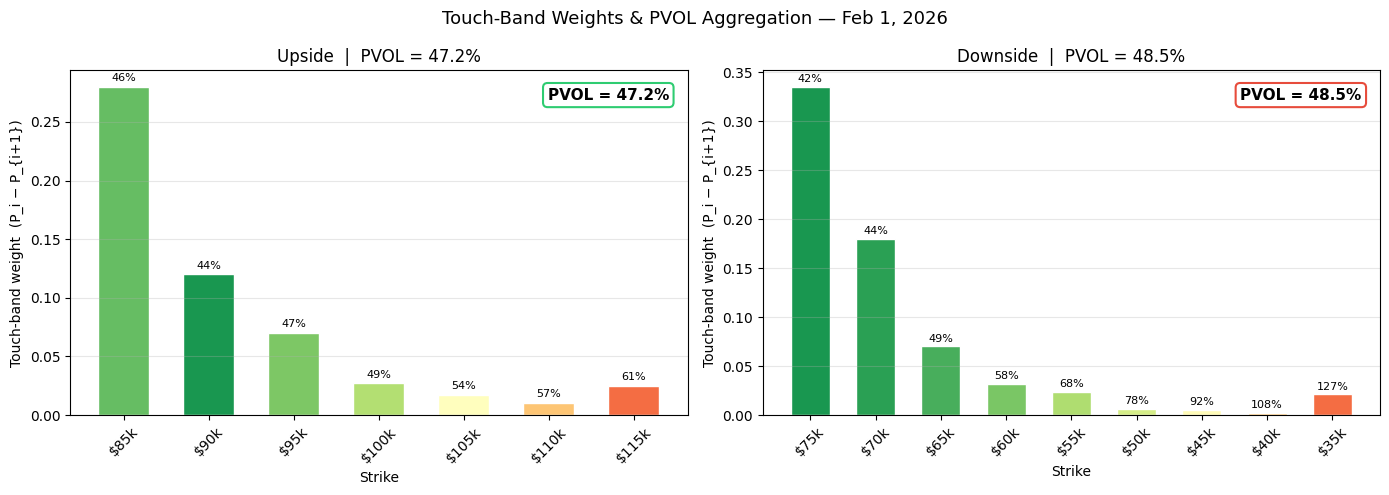

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Touch-Band Weights & PVOL Aggregation — Feb 1, 2026', fontsize=13)

for ax, weights_df, pvol_val, label, color in [
    (axes[0], up_weights,   pvol_up,   'Upside',   '#2ecc71'),
    (axes[1], down_weights, pvol_down, 'Downside', '#e74c3c'),
]:
    strike_labels = [f"${int(h/1000)}k" for h in weights_df['strike']]
    w = weights_df['weight'].values
    s = weights_df['sigma'].values

    # Bar height = weight (how much this rung contributes to the index)
    # Bar color = implied vol level at that strike (light = low vol, dark = high vol)
    norm_sigma = (s - s.min()) / (s.max() - s.min() + 1e-9)
    bar_colors = [plt.cm.RdYlGn_r(v * 0.7 + 0.1) for v in norm_sigma]

    bars = ax.bar(strike_labels, w, color=bar_colors, edgecolor='white', width=0.6)

    # Annotate each bar with its σ
    for bar, sigma in zip(bars, s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{sigma:.0%}', ha='center', va='bottom', fontsize=8)

    # PVOL line
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Strike')
    ax.set_ylabel('Touch-band weight  (P_i − P_{i+1})')
    ax.set_title(f'{label}  |  PVOL = {pvol_val:.1%}')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

    # PVOL annotation
    ax.text(0.97, 0.95, f'PVOL = {pvol_val:.1%}', transform=ax.transAxes,
            ha='right', va='top', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, linewidth=1.5))

plt.tight_layout()
plt.show()

---
## Step 5 — Data Quality Flags (MODEL.md §7)

Six flags are defined. They are emitted per snapshot and surface on the dashboard as warnings.

| Flag | Condition |
|---|---|
| `near_expiry` | T < 7 days |
| `non_monotone_ladder` | Any rungs were dropped in Step 2 |
| `insufficient_valid_strikes` | Fewer than 2 valid rungs after cleaning |
| `clamped_probability` | Any P_hat was clamped at ε |
| `missing_midpoint_fallback` | Any rung used last-traded-price (no bid/ask) |
| `large_bid_ask_spread` | Any rung has (ask − bid) / mid > 10% |

For this Feb 1 snapshot we expect:
- `non_monotone_ladder` = **True** (the $120k rung was dropped)
- `missing_midpoint_fallback` = **True** (no bid/ask in this dataset)
- All others = **False**

In [10]:
NEAR_EXPIRY_DAYS      = 7
LARGE_SPREAD_THRESHOLD = 0.10

def compute_flags(
    T: float,
    up_flagged: bool,
    down_flagged: bool,
    df_valid: pd.DataFrame,
    raw_ladder: list[dict],   # list of {yes_price, yes_bid, yes_ask}
) -> dict[str, bool]:
    """
    Evaluate all MODEL.md §7 data quality flags for one snapshot.
    """
    flags = {}

    # near_expiry
    flags['near_expiry'] = T < NEAR_EXPIRY_DAYS / 365.25

    # non_monotone_ladder
    flags['non_monotone_ladder'] = up_flagged or down_flagged

    # insufficient_valid_strikes
    n_valid = df_valid['valid'].sum()
    flags['insufficient_valid_strikes'] = int(n_valid) < 2

    # clamped_probability — check if any P_hat hit the epsilon boundary
    flags['clamped_probability'] = any(
        r['yes_price'] <= EPSILON or r['yes_price'] >= 1.0 - EPSILON
        for r in raw_ladder
    )

    # missing_midpoint_fallback — True if any rung had no bid/ask
    flags['missing_midpoint_fallback'] = any(
        r.get('yes_bid') is None or r.get('yes_ask') is None
        for r in raw_ladder
    )

    # large_bid_ask_spread — only checkable when bid/ask exists
    large_spread = False
    for r in raw_ladder:
        if r.get('yes_bid') is not None and r.get('yes_ask') is not None:
            mid = (r['yes_bid'] + r['yes_ask']) / 2.0
            if mid > 0 and (r['yes_ask'] - r['yes_bid']) / mid > LARGE_SPREAD_THRESHOLD:
                large_spread = True
                break
    flags['large_bid_ask_spread'] = large_spread

    return flags


# ── Build raw_ladder list for flag evaluation ──────────────────────────────────
# (bid/ask not available in this dataset — all None)
raw_ladder = [
    {'yes_price': p, 'yes_bid': None, 'yes_ask': None}
    for p in list(upside_raw.values()) + list(downside_raw.values())
]

flags = compute_flags(T, up_flagged, down_flagged, df_all, raw_ladder)

print('DATA QUALITY FLAGS — Feb 1, 2026 snapshot')
print()
for flag, value in flags.items():
    status = '⚠  TRUE ' if value else '   false'
    print(f'  {status}  {flag}')

DATA QUALITY FLAGS — Feb 1, 2026 snapshot

     false  near_expiry
  ⚠  TRUE   non_monotone_ladder
     false  insufficient_valid_strikes
     false  clamped_probability
  ⚠  TRUE   missing_midpoint_fallback
     false  large_bid_ask_spread


---
## Summary

Full pipeline result for this snapshot.

In [11]:
print('=' * 55)
print('  PVOL SNAPSHOT — Feb 1, 2026')
print('=' * 55)
print(f'  Spot                : ${SPOT:,.0f}')
print(f'  Days to expiry      : {T * 365.25:.1f}')
print()
print(f'  PVOL (upside)       : {pvol_up:.1%}   ({len(up_weights)} rungs)')
print(f'  PVOL (downside)     : {pvol_down:.1%}  ({len(down_weights)} rungs)')
print(f'  PVOL (combined)     : {pvol_combined:.1%}  ({int(df_all["valid"].sum())} rungs)')
print()
print('  Active flags:')
active = [k for k, v in flags.items() if v]
if active:
    for f in active:
        print(f'    ⚠  {f}')
else:
    print('    none')
print('=' * 55)

  PVOL SNAPSHOT — Feb 1, 2026
  Spot                : $78,726
  Days to expiry      : 28.0

  PVOL (upside)       : 47.2%   (7 rungs)
  PVOL (downside)     : 48.5%  (9 rungs)
  PVOL (combined)     : 49.8%  (16 rungs)

  Active flags:
    ⚠  non_monotone_ladder
    ⚠  missing_midpoint_fallback
